In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/validation.csv
/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/train.csv
/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/test.csv
/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/label_map.json


KeyboardInterrupt: 

In [10]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class EuroSATDataset(Dataset):
    def __init__(self, csv_path, img_root, transform=None):
        self.df = pd.read_csv(csv_path).drop(columns=['Unnamed: 0'])
        self.img_root = img_root
        self.transform = transform
        
        # Check what columns exist
        print(self.df.columns.tolist())
        print(self.df.head(2))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Adjust column names after checking df.head() above
        img_path = os.path.join(self.img_root, row['Filename'])
        label    = row['Label']
        
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


IMG_ROOT = "/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT"
CSV_ROOT = "/kaggle/input/datasets/apollo2506/eurosat-dataset"

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_ds = EuroSATDataset(r"/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT/train.csv",      IMG_ROOT, transform_train)
val_ds   = EuroSATDataset(r"/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT/validation.csv", IMG_ROOT, transform_eval)
test_ds  = EuroSATDataset(r"/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT/test.csv",       IMG_ROOT, transform_eval)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

['Filename', 'Label', 'ClassName']
                                            Filename  Label  \
0                      AnnualCrop/AnnualCrop_142.jpg      0   
1  HerbaceousVegetation/HerbaceousVegetation_2835...      2   

              ClassName  
0            AnnualCrop  
1  HerbaceousVegetation  
['Filename', 'Label', 'ClassName']
                   Filename  Label ClassName
0  Pasture/Pasture_1481.jpg      5   Pasture
1    Forest/Forest_2638.jpg      1    Forest
['Filename', 'Label', 'ClassName']
                          Filename  Label    ClassName
0   AnnualCrop/AnnualCrop_1275.jpg      0   AnnualCrop
1  Residential/Residential_504.jpg      7  Residential
Train: 18900 | Val: 5400 | Test: 2700


In [11]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT/train.csv")
print(df.columns.tolist())
print(df.head(3))

['Unnamed: 0', 'Filename', 'Label', 'ClassName']
   Unnamed: 0                                           Filename  Label  \
0       16257                      AnnualCrop/AnnualCrop_142.jpg      0   
1        3297  HerbaceousVegetation/HerbaceousVegetation_2835...      2   
2       17881               PermanentCrop/PermanentCrop_1073.jpg      6   

              ClassName  
0            AnnualCrop  
1  HerbaceousVegetation  
2         PermanentCrop  


In [12]:
# After loading train_ds
class_names = sorted(train_ds.df['ClassName'].unique().tolist())
num_classes  = len(class_names) 
print(class_names)

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [28]:
classes = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

In [35]:
train_ds.df['ClassName'].value_counts()*100/len(train_ds.df['ClassName'])

ClassName
AnnualCrop              11.111111
HerbaceousVegetation    11.111111
SeaLake                 11.111111
Forest                  11.111111
Residential             11.111111
PermanentCrop            9.259259
Industrial               9.259259
Highway                  9.259259
River                    9.259259
Pasture                  7.407407
Name: count, dtype: float64

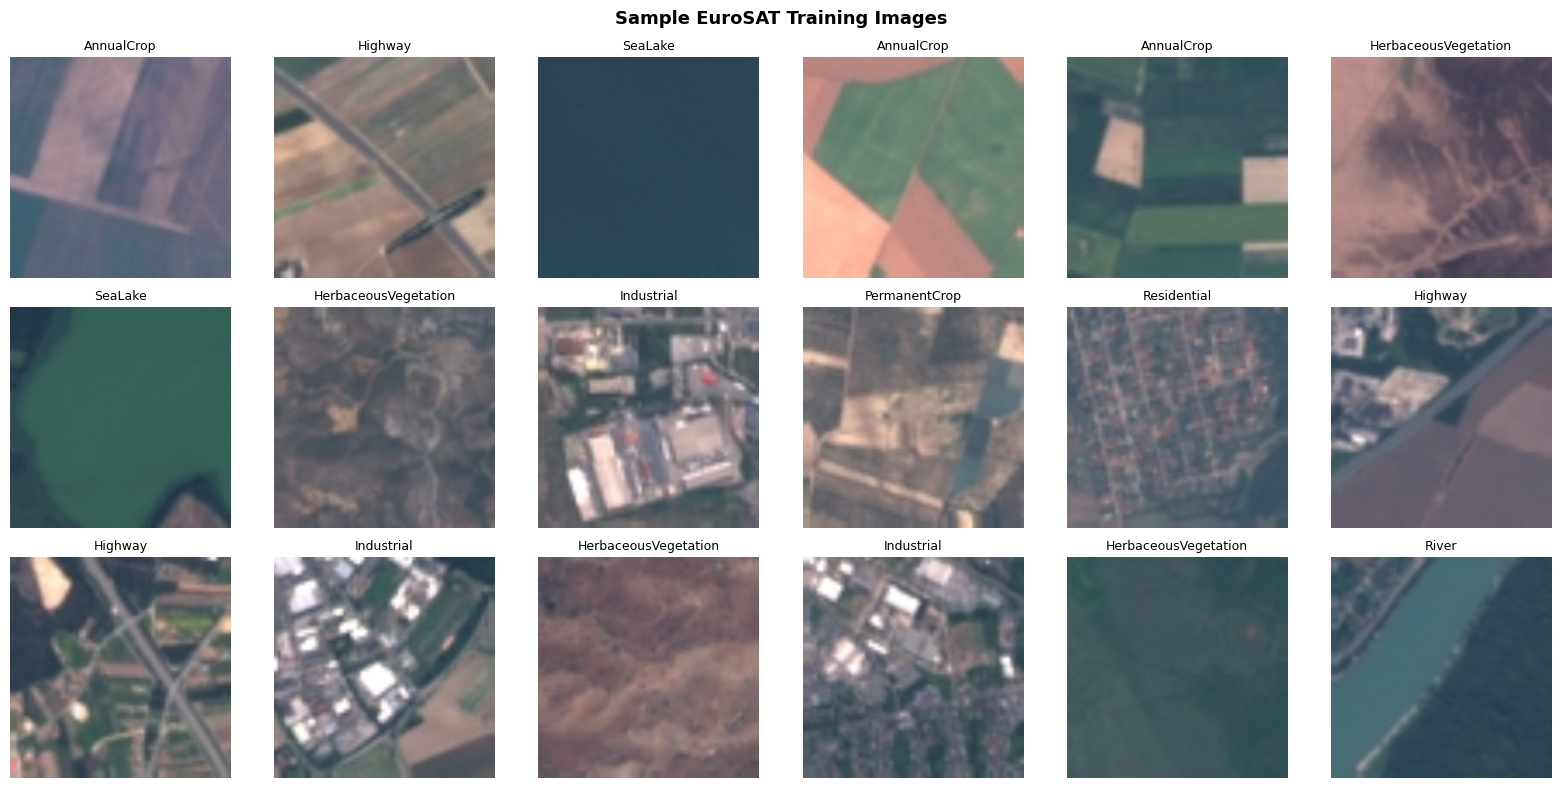

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.permute(1, 2, 0).numpy()
    img  = std * img + mean
    return np.clip(img, 0, 1)

# Grab one batch
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
axes = axes.flatten()

for i in range(18):
    axes[i].imshow(denormalize(images[i]))
    axes[i].set_title(class_names[labels[i]], fontsize=9)
    axes[i].axis('off')

plt.suptitle("Sample EuroSAT Training Images", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
import torch
import torch.nn as nn
from torchvision import models

def build_resnet50(num_classes=10, pretrained=True):
    model = models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)
    
    for param in model.parameters():
        param.requires_grad = False
    
    in_features = model.fc.in_features  
    model.fc = nn.Linear(in_features, num_classes)

    return model

model = build_resnet50(num_classes=10, pretrained=True)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)

print(model.fc)         
print(f"Device: {device}")

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / Total: {total:,}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s] 


Linear(in_features=2048, out_features=10, bias=True)
Device: cuda
Trainable params: 20,490 / Total: 23,528,522


In [19]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR

# ── Config ──────────────────────────────────────────
EPOCHS    = 10
LR        = 1e-3
STEP_SIZE = 3     
GAMMA     = 0.1  

# ── Loss & Optimizer ─────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)
scheduler = StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)

# ── Helper: one epoch of training ────────────────────
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct = 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset) * 100
    return avg_loss, accuracy


# ── Helper: validation ───────────────────────────────
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset) * 100
    return avg_loss, accuracy


# ── Main Training Loop ───────────────────────────────
history = {'train_loss': [], 'val_loss': [],
           'train_acc' : [], 'val_acc' : []}

best_val_acc = 0.0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'resnet50_eurosat_best.pth')

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print(f"\nBest Val Accuracy: {best_val_acc:.2f}%")

Epoch [01/10] Train Loss: 0.4998 | Train Acc: 84.69% | Val Loss: 0.2518 | Val Acc: 91.69%
Epoch [02/10] Train Loss: 0.2995 | Train Acc: 89.82% | Val Loss: 0.2200 | Val Acc: 92.26%
Epoch [03/10] Train Loss: 0.2691 | Train Acc: 90.78% | Val Loss: 0.1883 | Val Acc: 93.57%
Epoch [04/10] Train Loss: 0.2167 | Train Acc: 92.60% | Val Loss: 0.1783 | Val Acc: 94.09%
Epoch [05/10] Train Loss: 0.2177 | Train Acc: 92.83% | Val Loss: 0.1767 | Val Acc: 94.37%
Epoch [06/10] Train Loss: 0.2168 | Train Acc: 92.63% | Val Loss: 0.1789 | Val Acc: 94.04%
Epoch [07/10] Train Loss: 0.2051 | Train Acc: 93.17% | Val Loss: 0.1730 | Val Acc: 94.22%
Epoch [08/10] Train Loss: 0.2077 | Train Acc: 93.15% | Val Loss: 0.1731 | Val Acc: 94.31%
Epoch [09/10] Train Loss: 0.2119 | Train Acc: 92.69% | Val Loss: 0.1720 | Val Acc: 94.15%
Epoch [10/10] Train Loss: 0.2109 | Train Acc: 92.77% | Val Loss: 0.1731 | Val Acc: 94.35%

Best Val Accuracy: 94.37%


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch

class_names = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
               'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
               'River', 'SeaLake']

# ── Load best model ──────────────────────────────────
model.load_state_dict(torch.load('/kaggle/working/resnet50_eurosat_best.pth'))
model.eval()

# ── Test Evaluation ──────────────────────────────────
all_preds  = []
all_labels = []
all_images = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds   = outputs.argmax(1)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
        all_images.append(images.cpu())

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()
all_images = torch.cat(all_images)

test_acc = (all_preds == all_labels).mean() * 100
print(f"Test Accuracy: {test_acc:.2f}%")

print(classification_report(all_labels, all_preds, target_names=class_names))

Test Accuracy: 94.74%
                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.98      0.96       300
              Forest       0.97      0.98      0.98       300
HerbaceousVegetation       0.93      0.92      0.93       300
             Highway       0.90      0.88      0.89       250
          Industrial       0.98      0.97      0.97       250
             Pasture       0.92      0.96      0.94       200
       PermanentCrop       0.94      0.90      0.92       250
         Residential       0.98      1.00      0.99       300
               River       0.90      0.88      0.89       250
             SeaLake       0.99      0.98      0.98       300

            accuracy                           0.95      2700
           macro avg       0.95      0.95      0.94      2700
        weighted avg       0.95      0.95      0.95      2700



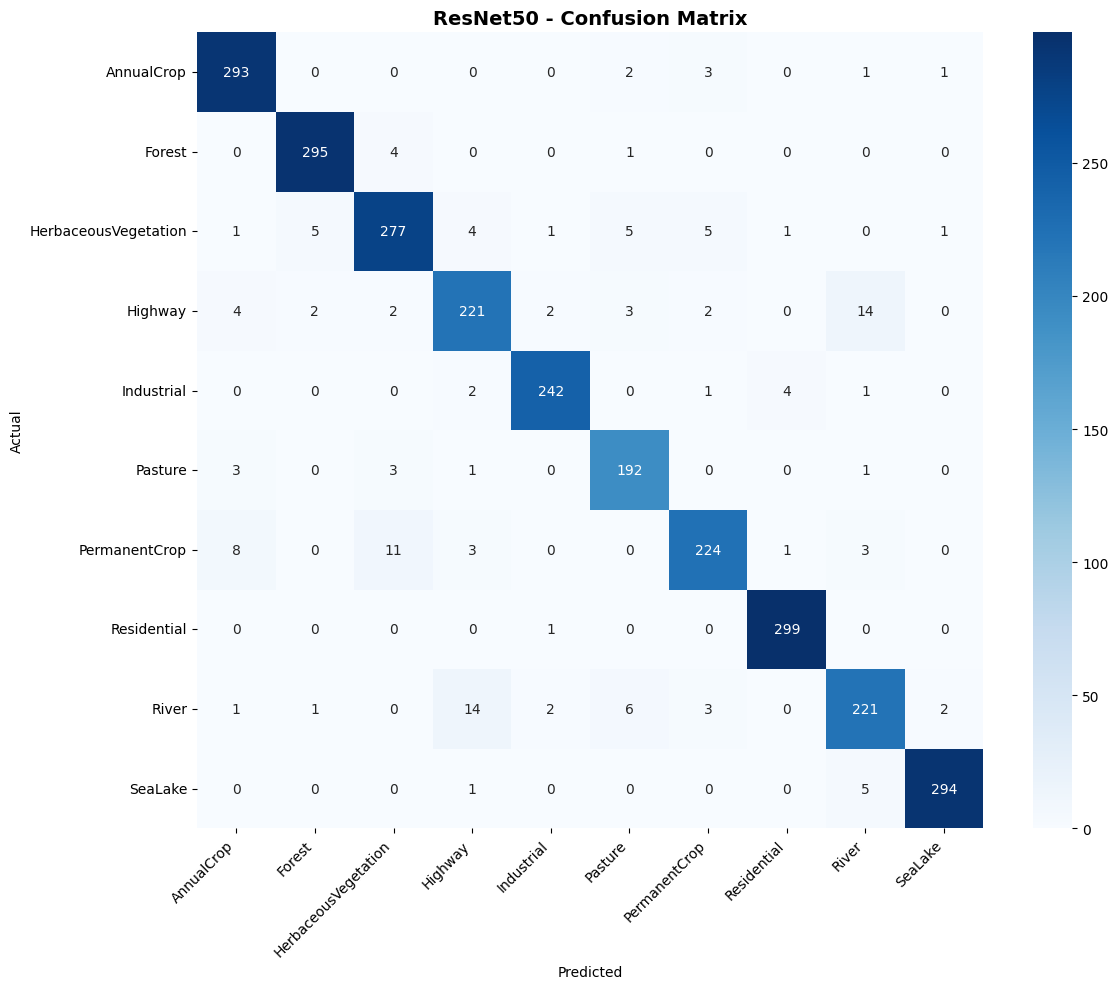

In [22]:

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('ResNet50 - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

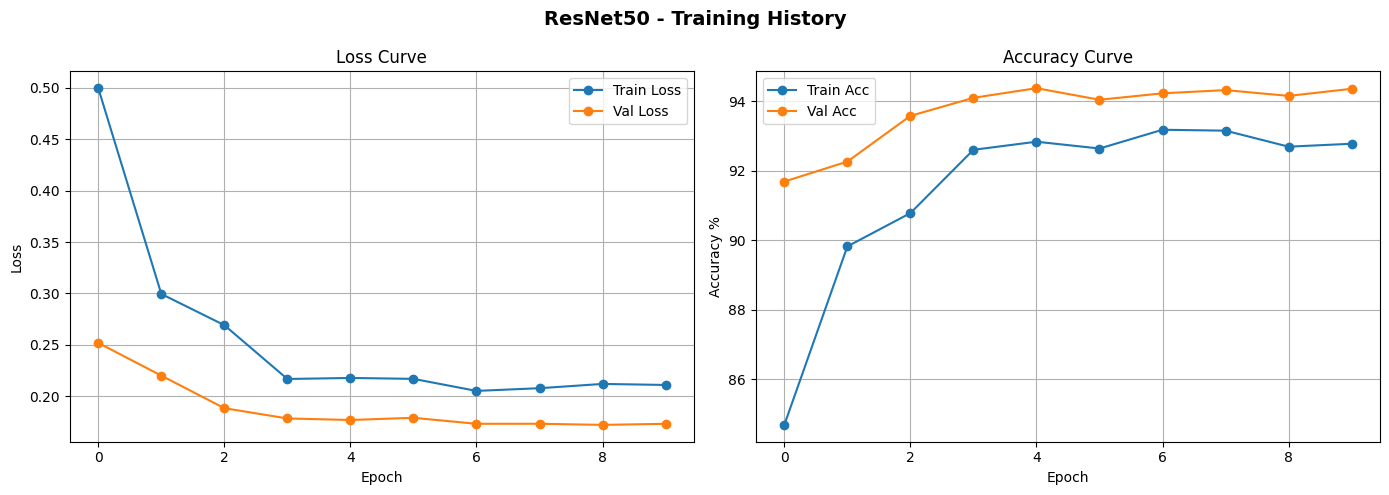

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'],   label='Val Loss',   marker='o')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['val_acc'],   label='Val Acc',   marker='o')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy %')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('ResNet50 - Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

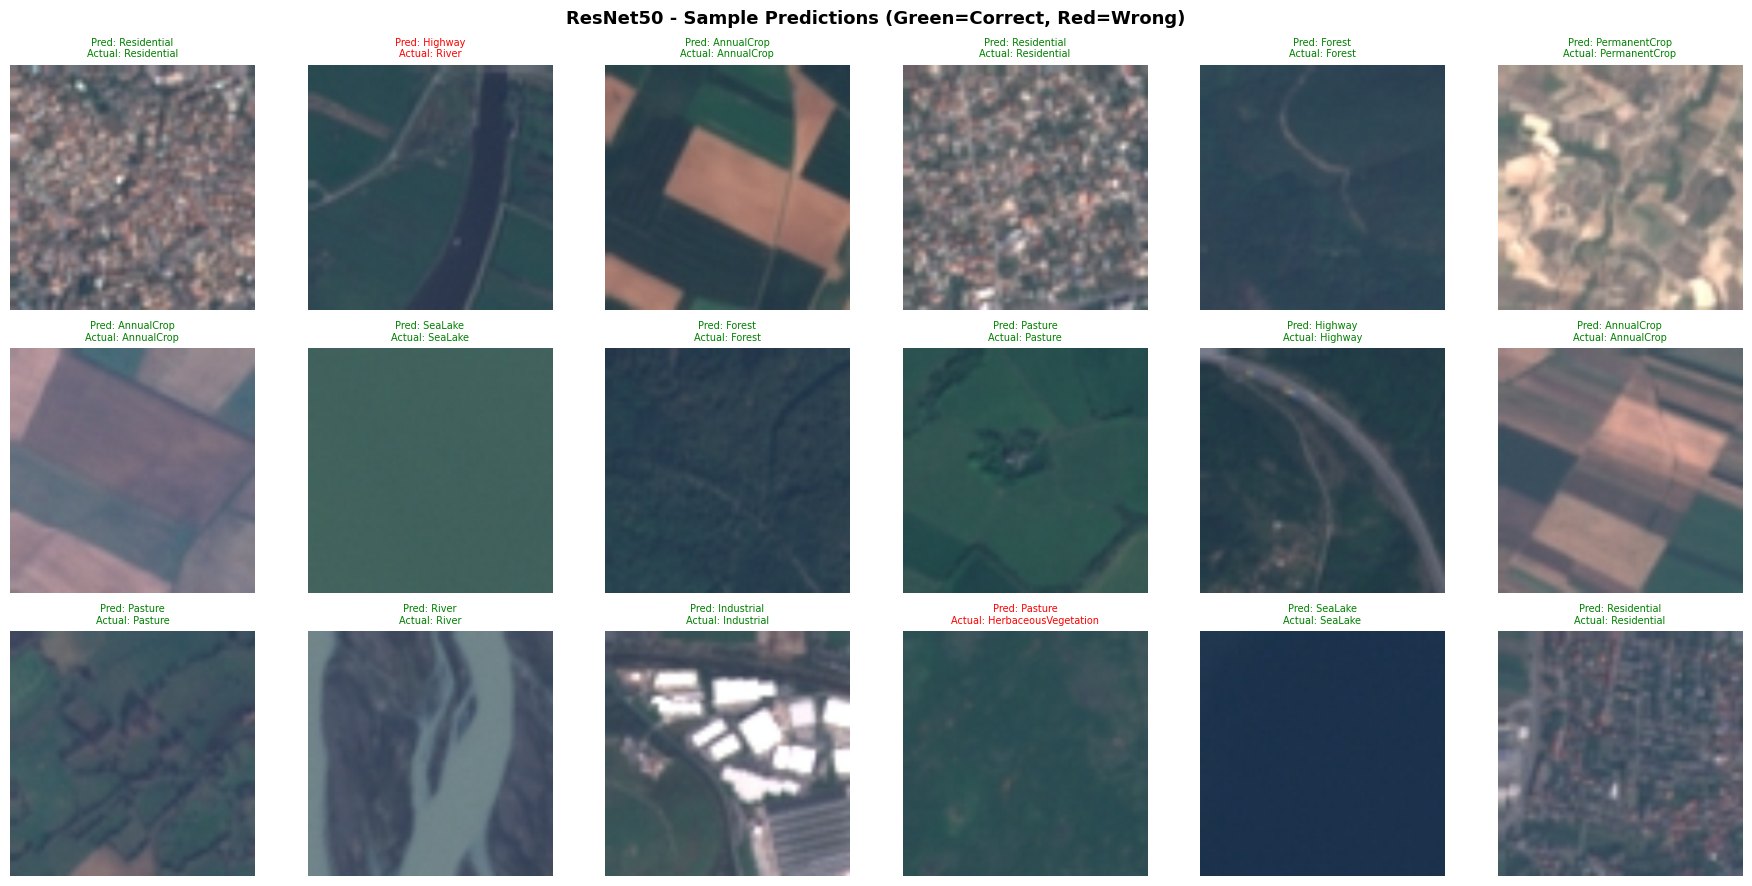

In [25]:

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.permute(1, 2, 0).numpy()
    img  = std * img + mean
    return np.clip(img, 0, 1)

indices = np.random.choice(len(all_images), 18, replace=False)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img    = denormalize(all_images[idx])
    pred   = class_names[all_preds[idx]]
    actual = class_names[all_labels[idx]]
    correct = all_preds[idx] == all_labels[idx]

    axes[i].imshow(img)
    axes[i].set_title(f"Pred: {pred}\nActual: {actual}",
                      fontsize=7,
                      color='green' if correct else 'red')
    axes[i].axis('off')

plt.suptitle('ResNet50 - Sample Predictions (Green=Correct, Red=Wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Insights :
- River → Highway (14 misclassified) — both are long narrow linear structures from satellite view, visually very similar
- PermanentCrop → HerbaceousVegetation (11) — both are green vegetation, hard to distinguish even for humans
- Highway → River (14) — same confusion happening both ways
PermanentCrop → AnnualCrop (8) — both are crop fields, subtle texture difference


Residential, Forest, SeaLake, AnnualCrop — nearly perfect, very distinct visual patterns

- no overfitting. Val loss is actually lower than train loss throughout, which means the model generalizes well.

- Why val loss < train loss?
Because you have RandomFlip augmentation on train data which makes training harder. Val has no augmentation so it's slightly easier for the model.


Accuracy plateaued around epoch 4 — both train and val accuracy stopped improving much after that. This tells you:

10 epochs was enough, more won't help much
The frozen layers are a bottleneck — only the final layer is training

In [39]:
import timm
import torch.nn as nn

def build_vit(num_classes=10, pretrained=True):
    # Load pretrained ViT from timm library
    model = timm.create_model('vit_small_patch16_224', 
                               pretrained=pretrained, 
                               num_classes=num_classes)
    return model

model_vit = build_vit(num_classes=10, pretrained=True)

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_vit = model_vit.to(device)

trainable = sum(p.numel() for p in model_vit.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_vit.parameters())
print(f"Device   : {device}")
print(f"Trainable: {trainable:,} / Total: {total:,}")

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Device   : cuda
Trainable: 21,669,514 / Total: 21,669,514


In [40]:
from tqdm import tqdm

EPOCHS    = 10
LR        = 1e-4    
STEP_SIZE = 3
GAMMA     = 0.1

criterion_vit = nn.CrossEntropyLoss()
optimizer_vit = Adam(model_vit.parameters(), lr=LR)
scheduler_vit = StepLR(optimizer_vit, step_size=STEP_SIZE, gamma=GAMMA)

history_vit = {'train_loss': [], 'val_loss': [],
               'train_acc' : [], 'val_acc' : []}

best_val_acc_vit = 0.0

for epoch in tqdm(range(EPOCHS), desc="Epochs"):
    train_loss, train_acc = train_one_epoch(
        model_vit, train_loader, optimizer_vit, criterion_vit, device
    )
    
    val_loss, val_acc = evaluate(
        model_vit, val_loader, criterion_vit, device
    )
    
    scheduler_vit.step()

    history_vit['train_loss'].append(train_loss)
    history_vit['val_loss'].append(val_loss)
    history_vit['train_acc'].append(train_acc)
    history_vit['val_acc'].append(val_acc)

    if val_acc > best_val_acc_vit:
        best_val_acc_vit = val_acc
        torch.save(model_vit.state_dict(), 'vit_eurosat_best.pth')

    tqdm.write(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
    )

print(f"\nBest Val Accuracy: {best_val_acc_vit:.2f}%")

Epochs:  10%|█         | 1/10 [03:52<34:52, 232.47s/it]

Epoch [01/10] Train Loss: 0.1621 | Train Acc: 94.62% | Val Loss: 0.0870 | Val Acc: 96.94%


Epochs:  20%|██        | 2/10 [07:46<31:07, 233.46s/it]

Epoch [02/10] Train Loss: 0.0674 | Train Acc: 97.84% | Val Loss: 0.0840 | Val Acc: 97.43%


Epochs:  30%|███       | 3/10 [11:40<27:16, 233.85s/it]

...

Epoch [08/10] Train Loss: 0.0026 | Train Acc: 99.95% | Val Loss: 0.0397 | Val Acc: 98.87%


Epochs:  90%|█████████ | 9/10 [34:56<03:52, 232.62s/it]

Epoch [09/10] Train Loss: 0.0023 | Train Acc: 99.95% | Val Loss: 0.0396 | Val Acc: 98.89%


Epochs: 100%|██████████| 10/10 [38:48<00:00, 232.90s/it]

Epoch [10/10] Train Loss: 0.0017 | Train Acc: 99.98% | Val Loss: 0.0396 | Val Acc: 98.89%

Best Val Accuracy: 98.89%


In [41]:

model_vit.load_state_dict(torch.load('vit_eurosat_best.pth'))
model_vit.eval()

all_preds_vit  = []
all_labels_vit = []
all_images_vit = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_vit(images)
        preds   = outputs.argmax(1)

        all_preds_vit.append(preds.cpu())
        all_labels_vit.append(labels.cpu())
        all_images_vit.append(images.cpu())

all_preds_vit  = torch.cat(all_preds_vit).numpy()
all_labels_vit = torch.cat(all_labels_vit).numpy()
all_images_vit = torch.cat(all_images_vit)

test_acc_vit = (all_preds_vit == all_labels_vit).mean() * 100
print(f"ViT Test Accuracy: {test_acc_vit:.2f}%")

print("\nClassification Report:")
print(classification_report(all_labels_vit, all_preds_vit, target_names=class_names))

ViT Test Accuracy: 99.00%

Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.99      0.98      0.99       300
              Forest       1.00      1.00      1.00       300
HerbaceousVegetation       0.98      0.99      0.98       300
             Highway       0.98      0.99      0.99       250
          Industrial       1.00      1.00      1.00       250
             Pasture       0.98      0.98      0.98       200
       PermanentCrop       0.98      0.98      0.98       250
         Residential       1.00      1.00      1.00       300
               River       0.98      0.98      0.98       250
             SeaLake       1.00      1.00      1.00       300

            accuracy                           0.99      2700
           macro avg       0.99      0.99      0.99      2700
        weighted avg       0.99      0.99      0.99      2700



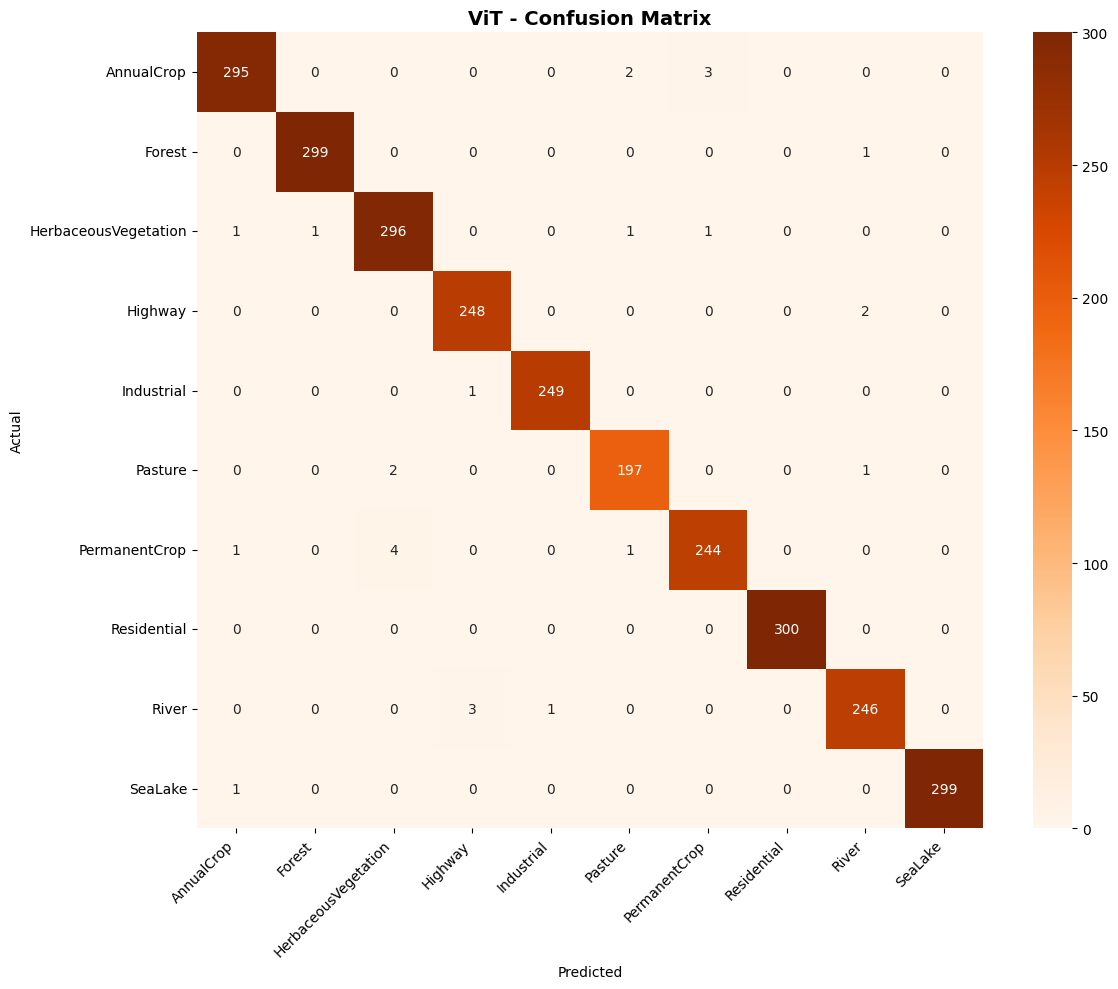

In [42]:

cm_vit = confusion_matrix(all_labels_vit, all_preds_vit)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_vit, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('ViT - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

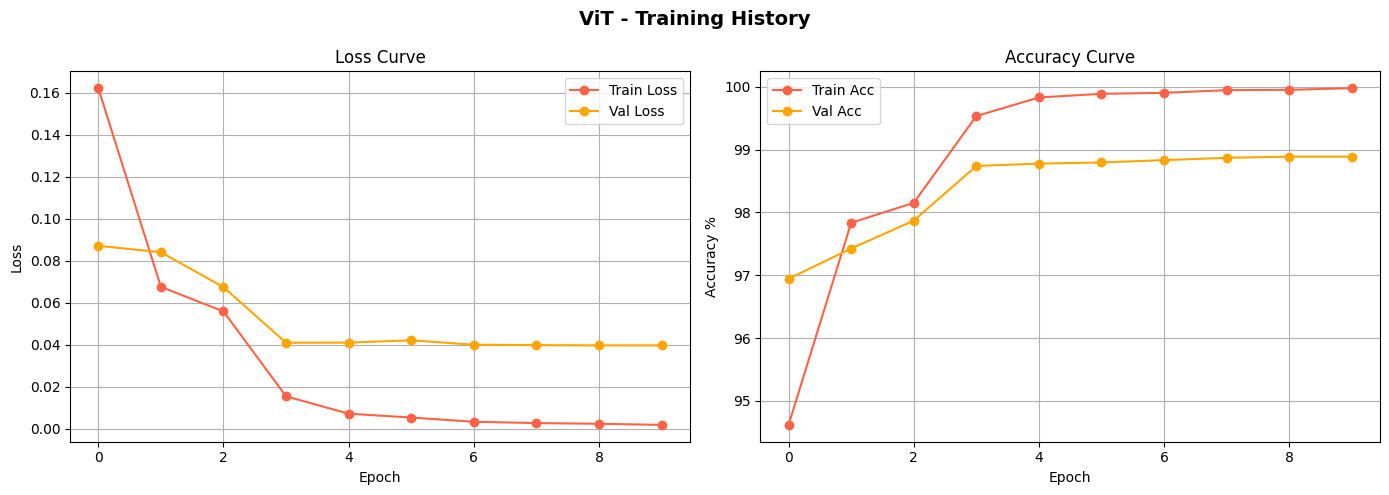

In [52]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_vit['train_loss'], label='Train Loss', marker='o', color='tomato')
axes[0].plot(history_vit['val_loss'],   label='Val Loss',   marker='o', color='orange')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_vit['train_acc'], label='Train Acc', marker='o', color='tomato')
axes[1].plot(history_vit['val_acc'],   label='Val Acc',   marker='o', color='orange')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy %')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('ViT - Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

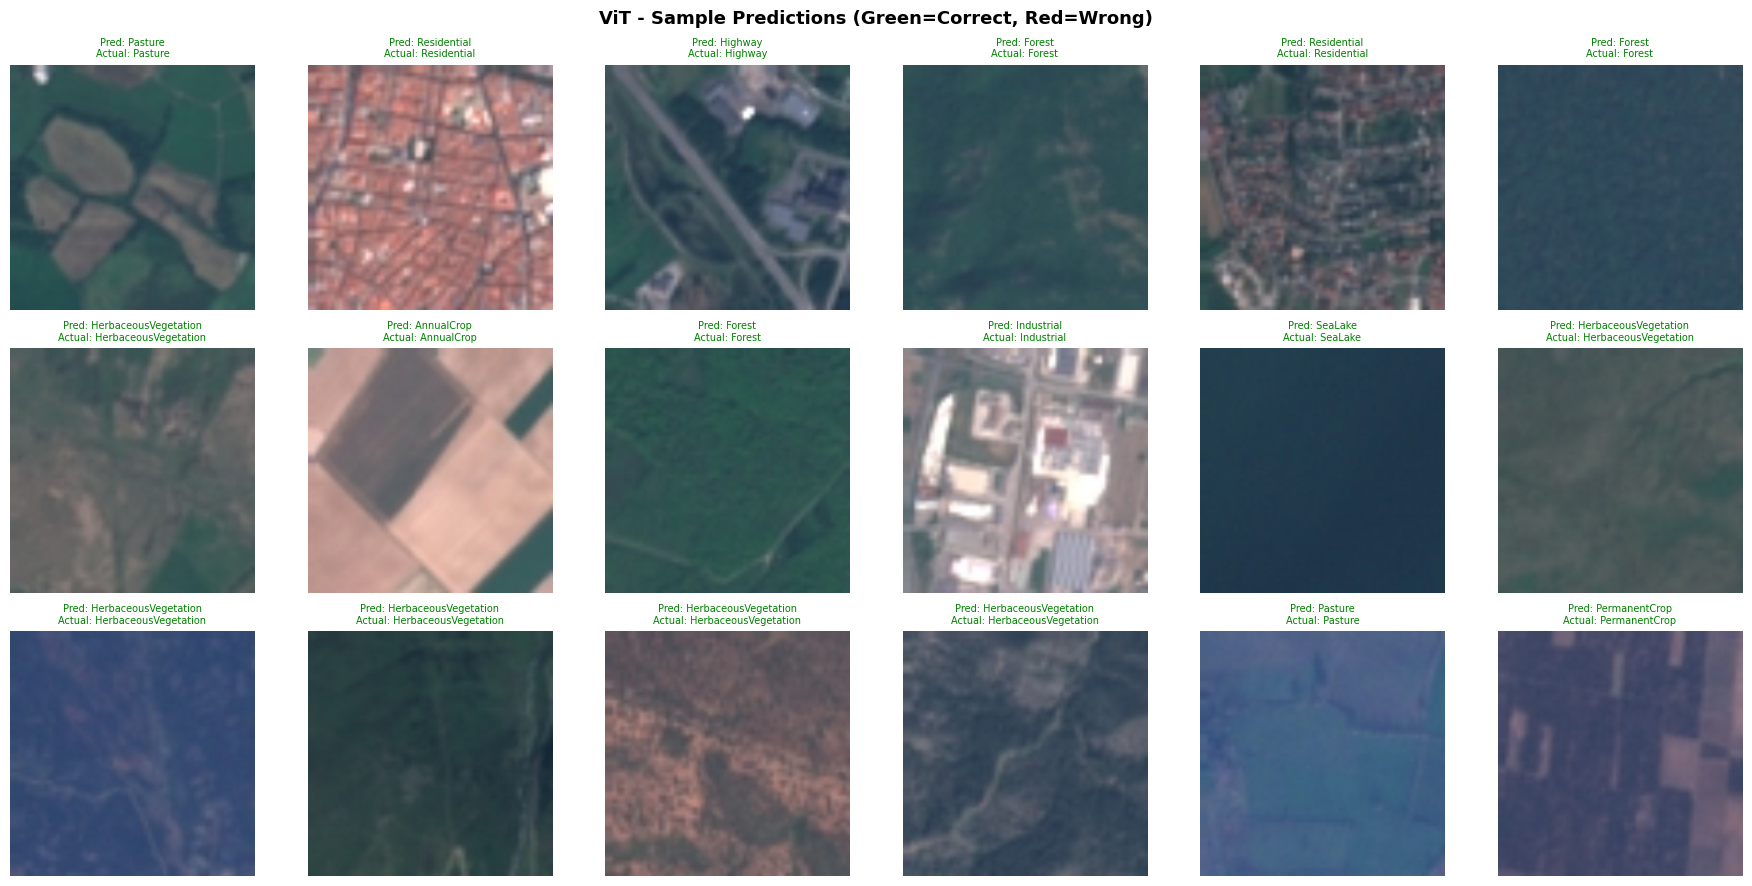

In [53]:

indices = np.random.choice(len(all_images_vit), 18, replace=False)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img     = denormalize(all_images_vit[idx])
    pred    = class_names[all_preds_vit[idx]]
    actual  = class_names[all_labels_vit[idx]]
    correct = all_preds_vit[idx] == all_labels_vit[idx]

    axes[i].imshow(img)
    axes[i].set_title(f"Pred: {pred}\nActual: {actual}",
                      fontsize=7,
                      color='green' if correct else 'red')
    axes[i].axis('off')

plt.suptitle('ViT - Sample Predictions (Green=Correct, Red=Wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [54]:
def build_vit_partial(num_classes=10):
    model = timm.create_model('vit_small_patch16_224',
                               pretrained=True,
                               num_classes=num_classes)
    # Freeze everything first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last 3 transformer blocks + head
    for param in model.blocks[-3:].parameters():
        param.requires_grad = True

    for param in model.head.parameters():
        param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"[Partial ViT] Trainable: {trainable:,} / Total: {total:,}")
    return model

In [60]:
from tqdm import tqdm

model_vit_partial = build_vit_partial(num_classes=10).to(device)

def train_model(model, model_name, epochs=10, lr=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=3, gamma=0.1)

    history   = {'train_loss': [], 'val_loss': [],
                 'train_acc' : [], 'val_acc' : []}
    best_acc  = 0.0

    for epoch in tqdm(range(epochs), desc=f"{model_name} Training"):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )
        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f'{model_name}_best.pth')

        tqdm.write(
            f"[{model_name}] Epoch [{epoch+1:02d}/{epochs}] "
            f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%"
        )

    print(f"\n[{model_name}] Best Val Acc: {best_acc:.2f}%\n")
    return history, best_acc


history_partial, best_partial = train_model(model_vit_partial, 'vit_partial', lr=1e-4)

[Partial ViT] Trainable: 5,327,242 / Total: 21,669,514


vit_partial Training:  10%|█         | 1/10 [02:05<18:52, 125.88s/it]

[vit_partial] Epoch [01/10] Train Acc: 93.57% | Val Acc: 96.65%


vit_partial Training:  20%|██        | 2/10 [04:11<16:45, 125.70s/it]

[vit_partial] Epoch [02/10] Train Acc: 98.06% | Val Acc: 97.04%


...

[vit_partial] Epoch [08/10] Train Acc: 99.96% | Val Acc: 97.81%


vit_partial Training:  90%|█████████ | 9/10 [18:49<02:05, 125.53s/it]

[vit_partial] Epoch [09/10] Train Acc: 99.96% | Val Acc: 97.81%


vit_partial Training: 100%|██████████| 10/10 [20:55<00:00, 125.56s/it]

[vit_partial] Epoch [10/10] Train Acc: 99.96% | Val Acc: 97.85%

[vit_partial] Best Val Acc: 97.85%



In [61]:
model_vit.load_state_dict(torch.load('/kaggle/working/vit_partial_best.pth'))

<All keys matched successfully>

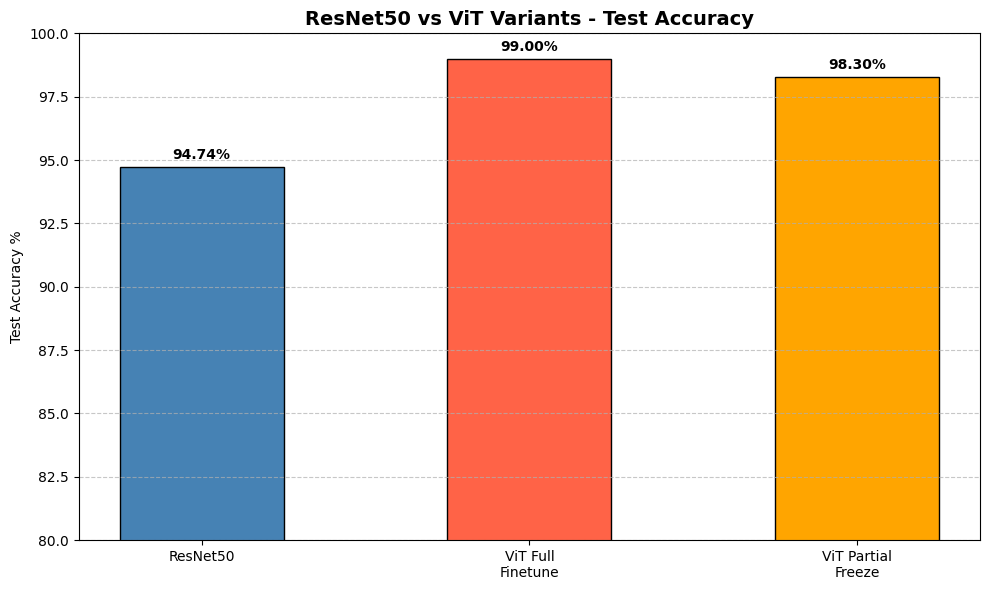

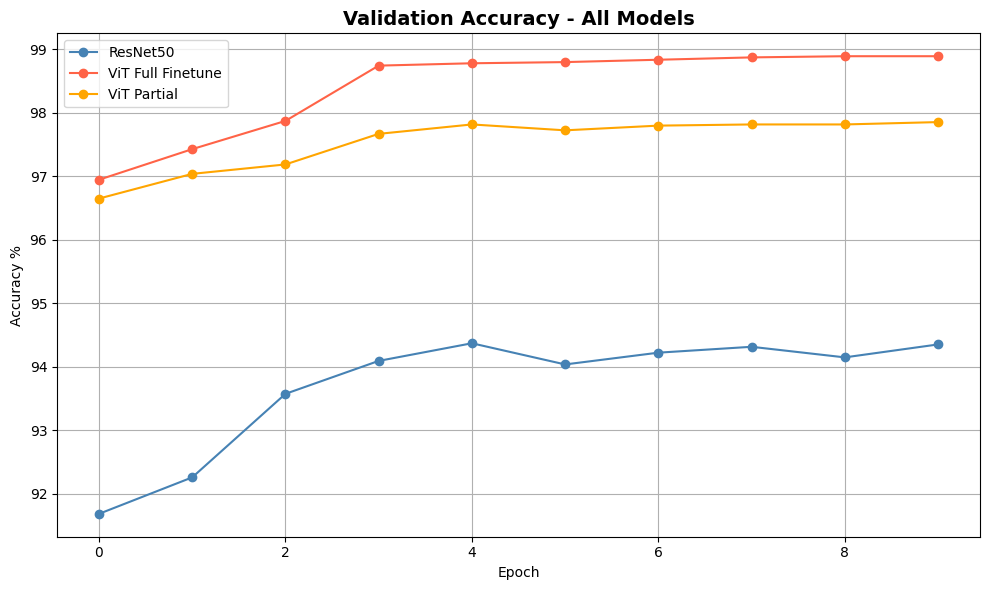


========== Final Results ==========
Model                       Test Acc
-------------------------------------
ResNet50                      94.74%
ViT Full Finetune             99.00%
ViT Partial Freeze            98.30%


In [62]:

def get_test_acc(model, path):
    model.load_state_dict(torch.load(path))
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            preds   = model(images).argmax(1)
            correct += (preds == labels).sum().item()
    return correct / len(test_loader.dataset) * 100

test_acc_resnet  = get_test_acc(model,            'resnet50_eurosat_best.pth')
test_acc_full    = get_test_acc(model_vit,         'vit_eurosat_best.pth')
test_acc_partial = get_test_acc(model_vit_partial, 'vit_partial_best.pth')

# ── Bar Chart ─────────────────────────────────────────
models      = ['ResNet50', 'ViT Full\nFinetune', 'ViT Partial\nFreeze']
accuracies  = [test_acc_resnet, test_acc_full, test_acc_partial]
colors      = ['steelblue', 'tomato', 'orange']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=colors, width=0.5, edgecolor='black')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{acc:.2f}%', ha='center', fontweight='bold')

plt.title('ResNet50 vs ViT Variants - Test Accuracy', fontsize=14, fontweight='bold')
plt.ylabel('Test Accuracy %')
plt.ylim(80, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ── Val Accuracy Curves All Models ────────────────────
plt.figure(figsize=(10, 6))
plt.plot(history['val_acc'],         label='ResNet50',         marker='o', color='steelblue')
plt.plot(history_vit['val_acc'],     label='ViT Full Finetune',marker='o', color='tomato')
plt.plot(history_partial['val_acc'], label='ViT Partial',      marker='o', color='orange')

plt.title('Validation Accuracy - All Models', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy %')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Summary Table ─────────────────────────────────────
print("\n========== Final Results ==========")
print(f"{'Model':<25} {'Test Acc':>10}")
print("-" * 37)
print(f"{'ResNet50':<25} {test_acc_resnet:>9.2f}%")
print(f"{'ViT Full Finetune':<25} {test_acc_full:>9.2f}%")
print(f"{'ViT Partial Freeze':<25} {test_acc_partial:>9.2f}%")
print("===================================")

- ViT dominates on EuroSAT — 4.26% gap over ResNet50 is significant. This makes sense because satellite image classification requires understanding global spatial context (what surrounds a crop field, how a river flows through a region) which ViT's self-attention captures perfectly. CNN only looks locally.
- ViT started strong from epoch 0 — ResNet50 started at 91.7% and slowly climbed. Both ViT variants started at 96-97% from epoch 0. This shows pretrained ViT transfers better to satellite imagery than pretrained ResNet50.
- ViT Partial Freeze (98.30%) is very close to Full Finetune (99.00%) — only 0.7% difference. This is a great finding — you get near full performance while training fewer parameters, saving time and memory.
- ResNet50 plateaued around 94-95% — couldn't improve further because only the final layer was training. If you had unfrozen last few ResNet layers it might have reached 96-97%.